# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR, SVAR
from statsmodels.tsa.vector_ar.irf import BaseIRAnalysis
from linearmodels.iv import IV2SLS
import scipy.optimize as opt

# Data generation

In [2]:
TRUE_EFFECT = -0.05
BS = 1

In [3]:
def generate_economic_data_DAG1(n_obs=1000, persistence=0.8, burn_in:int=100, seasonality:bool=True, shock:bool=False, shock_pos:int=510, shock_var:str="w", seed:int=42):
    """
    Generate synthetic economic data with known causal structure
    - w_t = 0.8 * w_{t-1} + u^w_t
    - d_t = d0 + persistence * y_{t-1} + true_effect * p_t + u^d_t + hd * h_t    ### y
    - s_t = s0 + B^s * p_t + 1.0 * w_t + u^s_t + hs * h_t                        ### y
    - d_t = s_t = y_t
    - p_t = x_t = (s0-d0 + 1.0*w_t - persistence*y_{t-1} + u^s_t - u^d_t) / (true_effect - B^s)
    - h_t = t % 2       ### seasonality, control variable, confounder

    """

    assert shock_var in ["w", "p", "q", "d", "s", "q_eng", "p_eng"]

    # Set random seed for reproducibility
    np.random.seed(seed)

    S_0 = 10
    # BS = 0.5
    h_s = 3.0 # represents solar pv

    D_0 = 30
    BD = TRUE_EFFECT
    AR1D = persistence
    h_d = 5.0 # represents more consumption during the day

    def supply(w_t:float, p_t:float, u_s:float, h_t:float, t:int) -> float:
        "gives the value of s_t"
        return S_0 + BS*p_t + w_t + u_s + h_s * h_t + (1 if shock and shock_var == "s" and t == shock_pos + burn_in else 0)             # Shock shifts supply to the right
    
    def demand(d_t1:float, p_t:float, u_d:float, h_t:float, t:int) -> float:
        "gives the value of d_t"
        return D_0 + AR1D * d_t1 + BD*p_t + u_d + h_d * h_t + (1 if shock and shock_var == "d" and t == shock_pos + burn_in else 0)     # Shock shifts demand to the right
    
    # Given that these two equations and the clearing condition D = S, one can solve for prices and quantities analytically

    # Initialize arrays
    q = np.zeros(n_obs + burn_in)  # y -> demanded and equilibrium quantity
    p = np.zeros(n_obs + burn_in)  # p -> equilibrium prices
    h = np.zeros(n_obs + burn_in)  # Confounder variable -> seasonality -> must be controlled on
    w = np.zeros(n_obs + burn_in)  # Instrument variable -> wind
    
    # Shocks
    uw = np.random.normal(0, 0.5, n_obs + burn_in)  # Structural shock to w (instrument shock)
    us = np.random.normal(0, 0.5, n_obs + burn_in)  # Structural shock to s  
    ud = np.random.normal(0, 0.5, n_obs + burn_in)  # Structural shock to d

    # Generate data with lag structure
    for t in range(1, n_obs + burn_in):
        w[t] = 0.8 * w[t-1] + uw[t] + (1 if shock and shock_var == "w" and t == shock_pos + burn_in else 0)                             # Shock increases wind
        h[t] = t % 2 if seasonality else 0

        def objective_function(price):                                                                                                  # The two endog shocks take place during clearing
            price = price - (1 if shock and shock_var == "p_eng" and t == shock_pos + burn_in else 0)                                   # This is the only shock that is -1 instead of 1. 
                                                                                                                                        # To effectively increase the price of electricity by 1 you have to make it so that paying a price p=a only gets you f(p=a-1)
            return (
                demand(p_t=price, d_t1=q[t-1], u_d=ud[t], h_t=h[t], t=t) - 
                supply(p_t=price, w_t=w[t], u_s=us[t], h_t=h[t], t=t) + 
                (1 if shock and shock_var == "q_eng" and t == shock_pos + burn_in else 0)                                               # In a way this is the opposite, you get one "extra unit" out of thin air that doesn't need to be supplied
            )

        result = opt.root_scalar(  # type: ignore
            objective_function,
            # args=(time,),
            bracket=[-100.0, 1000.0],
            method="brentq",
            xtol=1e-12,
        )
        if not result.converged:
            raise ValueError("Failed to find clearing price")
        price = result.root

        p[t] = price + (1 if shock and shock_var == "p" and t == shock_pos + burn_in else 0)                                            # These shocks are exogenous. The come on top of the market so they do not affect the clearing process
        q[t] = demand(p_t=price, d_t1=q[t-1], u_d=ud[t], h_t=h[t], t=t) + (1 if shock and shock_var == "q" and t == shock_pos + burn_in else 0)
    
    # Remove burn-in period
    data = pd.DataFrame({
        'y': q[burn_in:],
        'x': p[burn_in:],
        'w': w[burn_in:],
        'h': h[burn_in:]
    })
    
    # Add lags for analysis
    for lag in range(1, 4):
        data[f'y_lag{lag}'] = data['y'].shift(lag)
        data[f'x_lag{lag}'] = data['x'].shift(lag)
        data[f'w_lag{lag}'] = data['w'].shift(lag)
        data[f'h_lag{lag}'] = data['h'].shift(lag)
    
    return data, BD



In [4]:
# Generate data
data, true_effect = generate_economic_data_DAG1(4000)
print("Data Overview:")
print(data.dropna().head())
print(f"\nTrue causal effect of x on y: {true_effect}")

Data Overview:
            y           x         w    h      y_lag1      x_lag1    w_lag1  \
3  133.936563  122.592646 -1.171212  1.0  131.245959  122.701320 -0.962592   
4  131.444650  122.406995 -1.017612  0.0  133.936563  122.592646 -1.171212   
5  134.436671  122.361893 -0.612065  1.0  131.444650  122.406995 -1.017612   
6  130.830739  120.130266  0.453441  0.0  134.436671  122.361893 -0.612065   
7  134.496696  122.473968  0.450042  1.0  130.830739  120.130266  0.453441   

   h_lag1      y_lag2      x_lag2    w_lag2  h_lag2      y_lag3      x_lag3  \
3     0.0  134.677261  123.211409 -0.989043     1.0  132.597268  123.448839   
4     1.0  131.245959  122.701320 -0.962592     0.0  134.677261  123.211409   
5     0.0  133.936563  122.592646 -1.171212     1.0  131.245959  122.701320   
6     1.0  131.444650  122.406995 -1.017612     0.0  133.936563  122.592646   
7     0.0  134.436671  122.361893 -0.612065     1.0  131.444650  122.406995   

     w_lag3  h_lag3  
3 -0.973400     0.0

# DAG based identification

In [5]:
def instrumental_variables_analysis(data:pd.DataFrame, conditional_set:list[str]=['w_lag1'], summary:bool=False):
    """Estimate causal effect using IV/2SLS"""
    
    # Prepare data
    data_iv = data.dropna().copy()
    
    # First stage: x ~ w + controls
    first_stage_X = sm.add_constant(data_iv[['w', 'h']+conditional_set])
    first_stage = sm.OLS(data_iv['x'], first_stage_X).fit()
    
    if summary:
        print("First Stage Results:")
        print(f"F-statistic: {first_stage.fvalue:.4f}")
        print(f"P-value: {first_stage.f_pvalue:.4f}")
        print(f"Coefficient on w: {first_stage.params['w']:.4f}")
        print(f"Analytical coefficient on w: {1.0 / (true_effect-0.5):.4f}")
    
    # Second stage: y ~ x_hat + controls
    data_iv['x_hat'] = first_stage.predict()
    second_stage_X = sm.add_constant(data_iv[['x_hat', 'h']+conditional_set])
    second_stage = sm.OLS(data_iv['y'], second_stage_X).fit()
    
    if summary:
        print("\nSecond Stage Results:")
        print(second_stage.summary())
    
    # Using linearmodels for robust IV estimation
    iv_formula = f'y ~ 1 + {" + ".join(cv for cv in conditional_set)} + h + [x ~ w]'
    iv_model = IV2SLS.from_formula(iv_formula, data_iv)
    iv_results = iv_model.fit(cov_type='robust')
    
    # print("\nIV/2SLS Results (using linearmodels):")
    # print(iv_results)
    # print(iv_results.conf_int(0.05))
    # print(second_stage.conf_int(0.05))

    ci = second_stage.conf_int(0.05).loc["x_hat"]
    print(f"True effect {true_effect} in confidence interval {float(round(ci[0], 4)), float(round(ci[1], 4))}? {ci[0] <= true_effect <= ci[1]}")
    
    return first_stage, second_stage, iv_results



In [6]:
print("\n*** Naive IV ***\n")
first_stage, second_stage, iv_results = instrumental_variables_analysis(data, conditional_set=[], summary=False)

print("\n*** CIV Wind ***\n")
first_stage, second_stage, iv_results = instrumental_variables_analysis(data, conditional_set=["w_lag1"], summary=True)

print("\n*** CIV Demand ***\n")
first_stage, second_stage, iv_results = instrumental_variables_analysis(data, conditional_set=["y_lag1"], summary=False)

print("\n*** CIV Wind & Demand ***\n")
first_stage, second_stage, iv_results = instrumental_variables_analysis(data, conditional_set=["w_lag1", "y_lag1"], summary=True)



*** Naive IV ***

True effect -0.05 in confidence interval (-0.1315, -0.0738)? False

*** CIV Wind ***

First Stage Results:
F-statistic: 1059.9098
P-value: 0.0000
Coefficient on w: -0.9449
Analytical coefficient on w: -1.8182

Second Stage Results:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     5313.
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:19:36   Log-Likelihood:                -4231.5
No. Observations:                3997   AIC:                             8471.
Df Residuals:                    3993   BIC:                             8496.
Df Model:                           3                                         
Covariance Type:            nonrobust 

In [7]:
def compare_with_ols(data):
    """Show biased OLS results for comparison"""
    data_ols = data.dropna().copy()
    
    # Biased OLS (doesn't account for simultaneity)
    ols_formula = 'y ~ x + w_lag1 + h'
    ols_model = sm.OLS.from_formula(ols_formula, data_ols)
    ols_results = ols_model.fit()
    
    print("Naive OLS Results (biased):")
    print(ols_results.summary())
    
    return ols_results

ols_results = compare_with_ols(data)

Naive OLS Results (biased):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                 1.103e+04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:19:36   Log-Likelihood:                -2991.0
No. Observations:                3997   AIC:                             5990.
Df Residuals:                    3993   BIC:                             6015.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     71.7929   

# SVAR analysis

In [ ]:
# Reduced Form VAR
def svar_analysis(data, lags=1, verbose:bool=True, reverse_causality:bool=False):
    """Estimate SVAR with identifying restrictions"""
    
    # Prepare data - include all endogenous variables
    svar_data = data[['y', 'x', 'w']]  # q_t, p_t, w_t
    # h_t is exogenous due to deterministic seasonality
    # and there is no way to parse exogenous variables to the SVAR.
    # If h_t is included, there is problems of rank

    # Matrix intuition:
    # - Y is contemporanously affected by X -> E
    # - Y is not contemporanously affected by W (exclusion restriction) -> 0
    # - X is contemporanously affected by W (relevance of instrument) -> E
    q_to_p = 0 if not reverse_causality else 'E'

    A_mask = np.array([
        [1,         'E',        0],
        [q_to_p,    1,          "E"],
        [0,         0,          1],
    ], dtype=object)
    
    # Reduced form VAR
    model = SVAR(endog=svar_data, svar_type="A", A=A_mask)
    if verbose:
        print("To be estimated:")
        print(model.A)

    var_result = model.fit(maxlags=lags)
    if verbose:
        print("Reduced Form SVAR Results:")
        print(model.A)
    
    return var_result, svar_data

In [48]:
svar_data, true_effect = generate_economic_data_DAG1(4000, seasonality=False)

var_result, svar_data = svar_analysis(svar_data, 1)

To be estimated:
[[ 1. nan  0.]
 [ 0.  1. nan]
 [ 0.  0.  1.]]
Reduced Form SVAR Results:
[[ 1.         -0.28954114  0.        ]
 [ 0.          1.          0.95845023]
 [ 0.          0.          1.        ]]


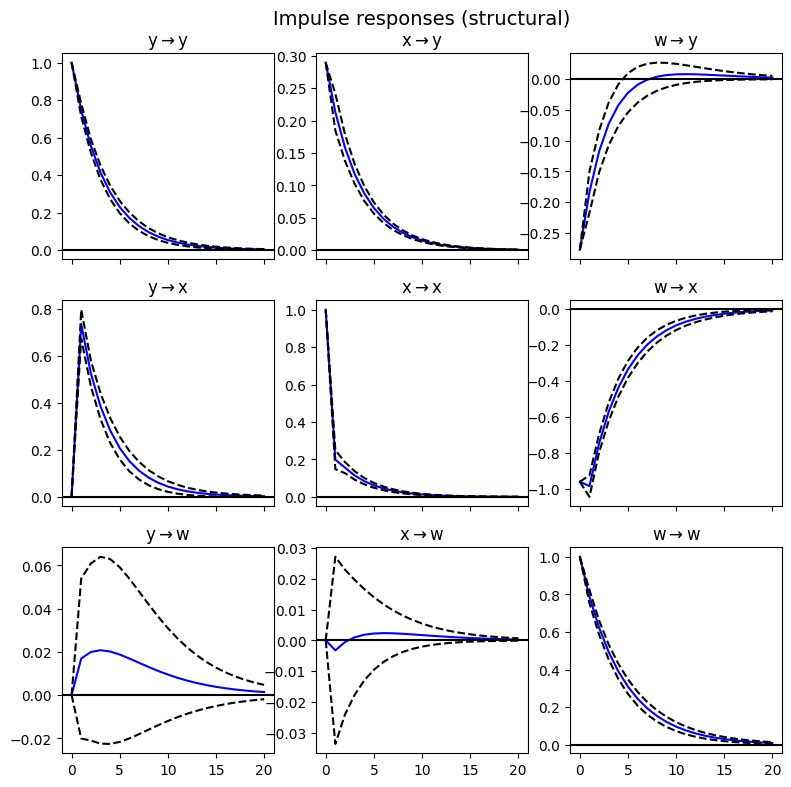

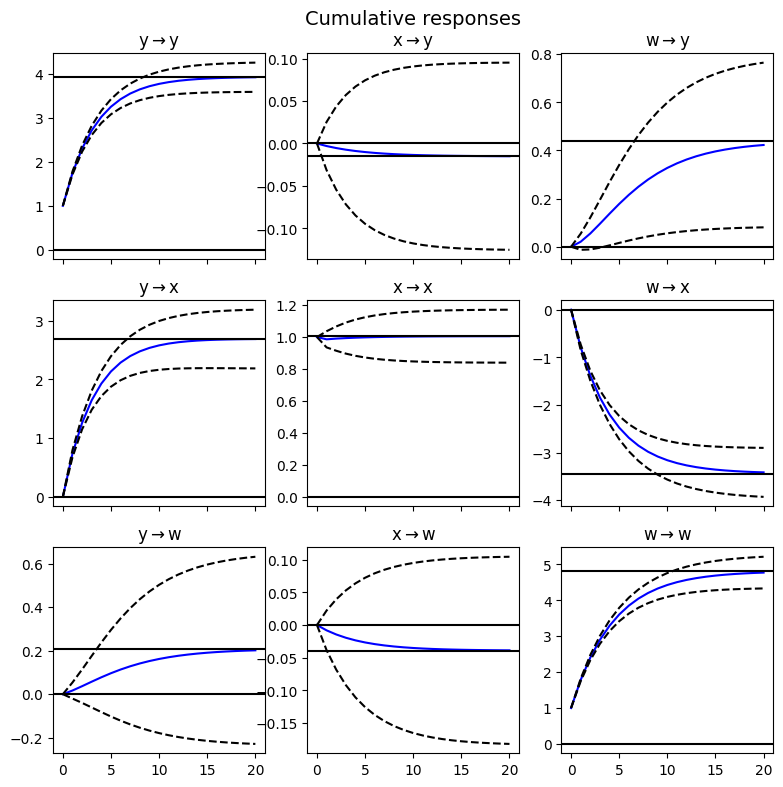

In [49]:
irf = var_result.irf(20)
fig = irf.plot(figsize=(8, 8))
fig = irf.plot_cum_effects(figsize=(8, 8))

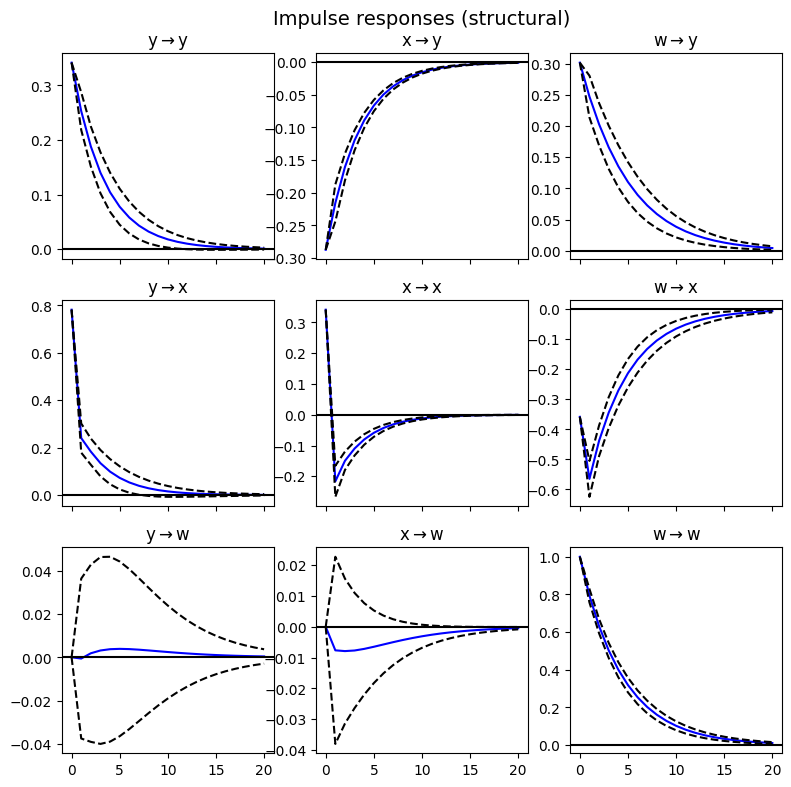

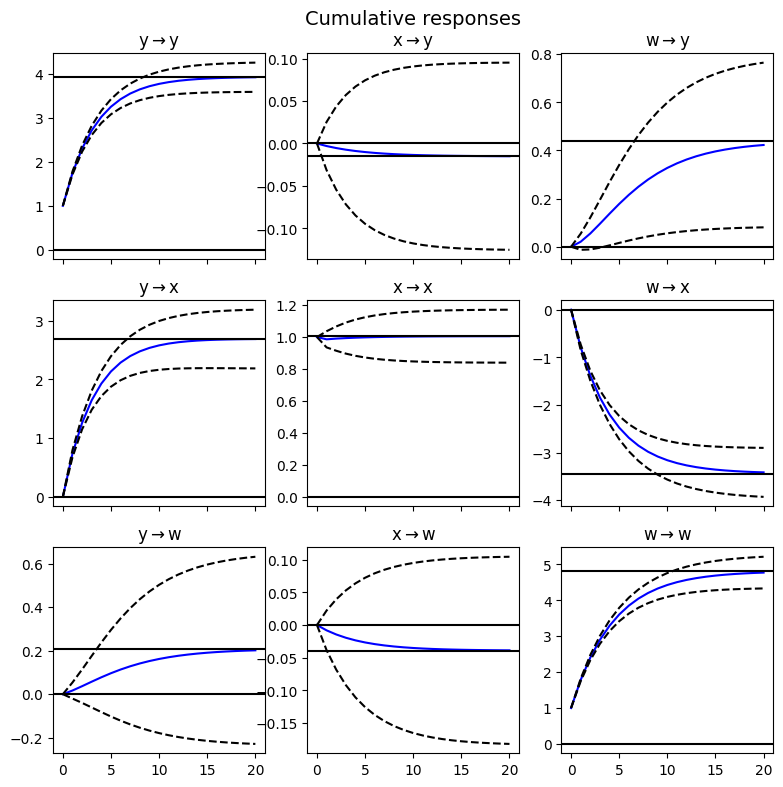

In [50]:
feedback_var_result, svar_data = svar_analysis(svar_data, 1, reverse_causality=True, verbose=False)

feedback_irf = feedback_var_result.irf(20)
fig = feedback_irf.plot(figsize=(8, 8))
fig = feedback_irf.plot_cum_effects(figsize=(8, 8))

 80%|████████  | 8/10 [00:01<00:00,  4.61it/s]c:\Users\Jorge Sanchez\Documents\Github\elasticities_with_graphs\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 90%|█████████ | 9/10 [00:02<00:00,  4.50it/s]c:\Users\Jorge Sanchez\Documents\Github\elasticities_with_graphs\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
100%|██████████| 10/10 [00:02<00:00,  4.48it/s]

true_effect=-0.05
a12 = -0.3014, a23 = 0.9481
a12 / a23 = -0.3179


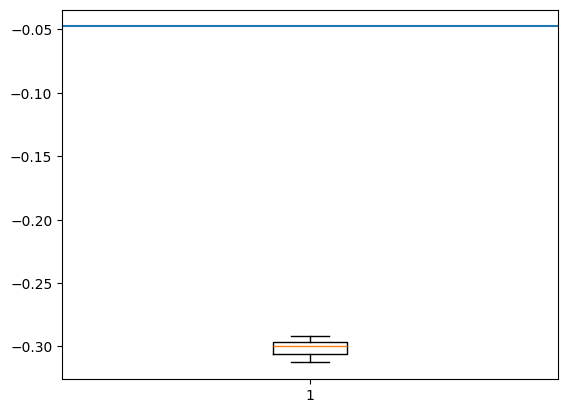

In [53]:
from tqdm import tqdm

def distr_of_h0(n:int=500):
    coeffs = []
    a23s = []
    
    for i in tqdm(range(n)):
        data, true_effect = generate_economic_data_DAG1(5000, seasonality=False, seed=np.random.randint(0, 1_000_000_000))
        var_result, svar_data = svar_analysis(data, 1, verbose=False)
        coeffs.append(var_result.A_solve[0][1])
        a23s.append(var_result.A_solve[1][2])

    plt.boxplot(coeffs)
    plt.axhline(-TRUE_EFFECT / (TRUE_EFFECT - BS))      # Why would the SVAR model retrieve this value? This is -B^P / (B^P + G^P)
    # Or put differently:

    print(f"{true_effect=}")

    a12 = np.mean(coeffs)    
    a23 = np.mean(a23s)    
    print(f"a12 = {float(round(a12, 4))}, a23 = {float(round(a23, 4))}")
    print(f"a12 / a23 = {float(round(a12 / a23, 4))}")

    # TODO: try this changing the values of BP and BS to see if this is consistent or not
    
distr_of_h0(10)


# IRFs with ground truth

In [14]:
def cut_data(df:pd.DataFrame, lb:int, ub:int) -> pd.DataFrame:
    return df[lb:ub]

def difference(df1:pd.DataFrame, df2:pd.DataFrame) -> pd.DataFrame:
    return df1 - df2

In [15]:
def plot_impulse_response(shock_pos:int, shock_var:str):
    df_shock,_ = generate_economic_data_DAG1(1000, shock=True, shock_pos=shock_pos, shock_var=shock_var)
    df_no_shock,_ = generate_economic_data_DAG1(1000, shock=False, shock_pos=shock_pos, shock_var=shock_var)

    lb = shock_pos - 5
    ub = shock_pos + 25
    df_shock = cut_data(df_shock, lb, ub+1)
    df_no_shock = cut_data(df_no_shock, lb, ub+1)
    df_diff = difference(df_shock, df_no_shock)
    

    fig, axss = plt.subplots(3, 1, figsize=(8, 6))
    axss[0].plot(df_diff["y"])
    axss[0].set_title(f"{shock_var} $\\rightarrow$ y")
    axss[1].plot(df_diff["x"])
    axss[1].set_title(f"{shock_var} $\\rightarrow$ x")
    axss[2].plot(df_diff["w"])
    axss[2].set_title(f"{shock_var} $\\rightarrow$ w")
    for ax in axss:
        ax.axhline(0, ls=":", color="k")
        ax.axvline(shock_pos, ls=":", color="darkorange")
        ax.set_xlim(lb, ub)

    print(df_diff[["y", "x", "w"]].loc[shock_pos])

    fig.tight_layout()
    fig.show()

y    0.047619
x   -0.952381
w    1.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


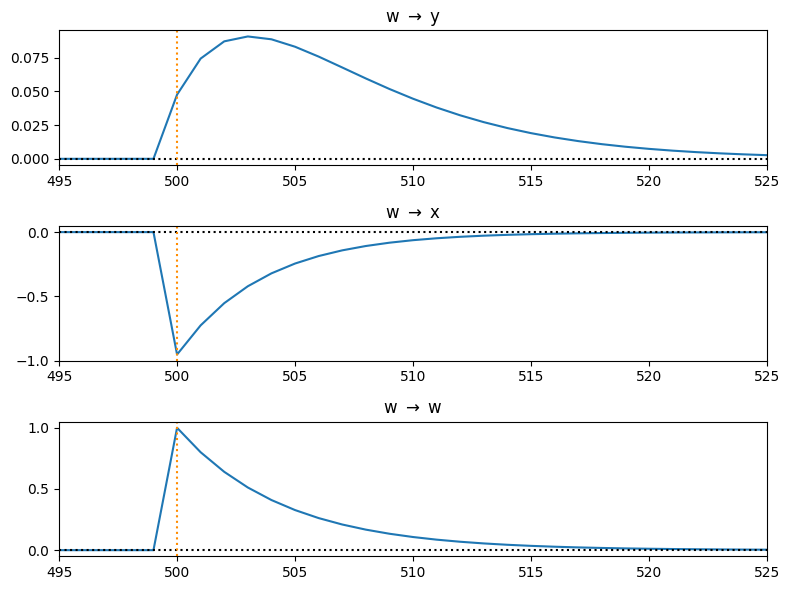

In [16]:
shock_pos = 500
plot_impulse_response(shock_pos=shock_pos, shock_var="w")

y    0.952381
x    0.952381
w    0.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


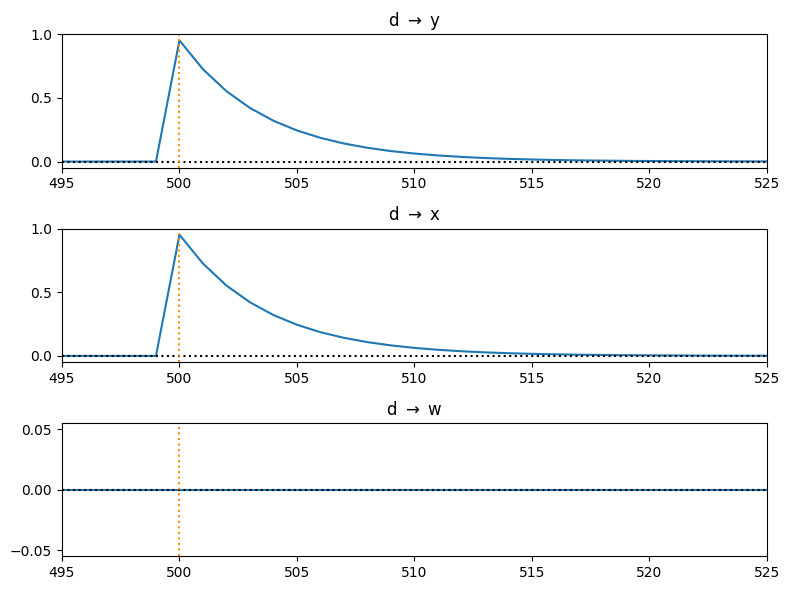

In [17]:
plot_impulse_response(shock_pos=shock_pos, shock_var="d")


y    0.047619
x   -0.952381
w    0.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


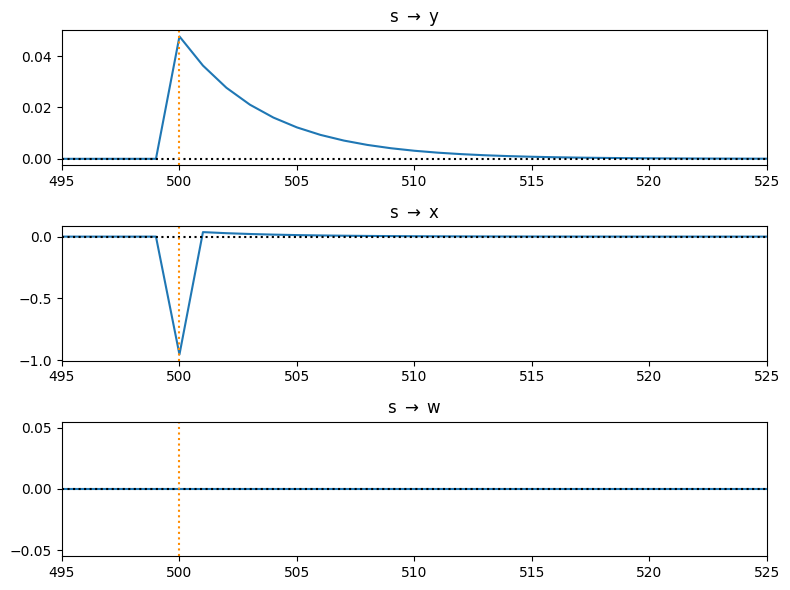

In [18]:
plot_impulse_response(shock_pos=shock_pos, shock_var="s")


y    1.0
x    0.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


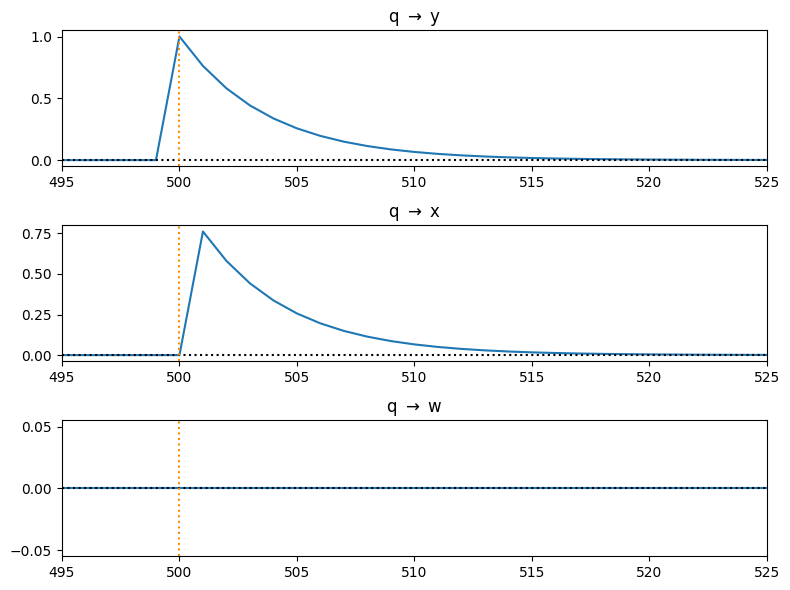

In [19]:
plot_impulse_response(shock_pos=shock_pos, shock_var="q")


y    0.0
x    1.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


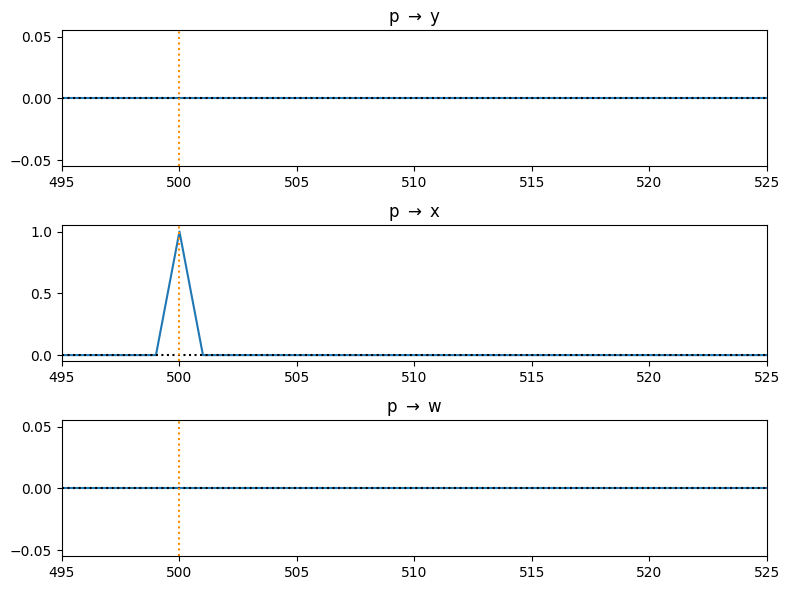

In [20]:
plot_impulse_response(shock_pos=shock_pos, shock_var="p")


y   -0.05
x    1.00
w    0.00
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


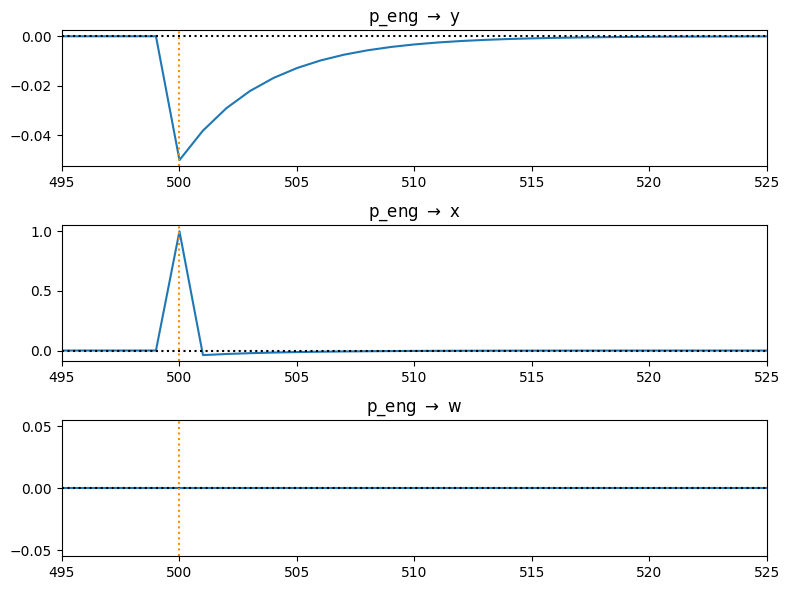

In [21]:
plot_impulse_response(shock_pos=shock_pos, shock_var="p_eng")
# This is our coefficient!
# This is our estimand!


y   -0.047619
x    0.952381
w    0.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1974774189.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


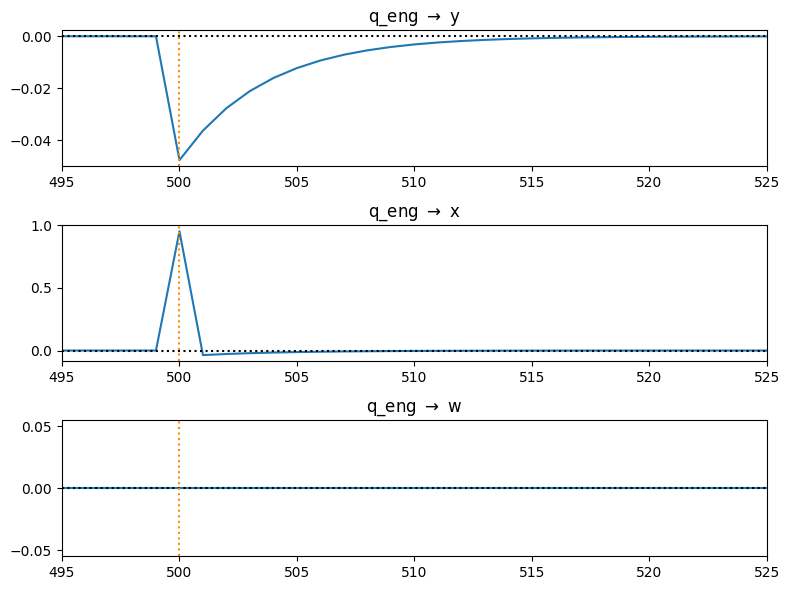

In [22]:
plot_impulse_response(shock_pos=shock_pos, shock_var="q_eng")


# Comparing SVAR with truth

In [23]:
def plot_irf_panel(shock_pos:int, shock_vars:list[str]):
    fig, axss = plt.subplots(3, 3, figsize=(8, 8))

    for i, sv in enumerate(shock_vars):
        df_shock,_ = generate_economic_data_DAG1(1000, shock=True, shock_pos=shock_pos, shock_var=sv)
        df_no_shock,_ = generate_economic_data_DAG1(1000, shock=False, shock_pos=shock_pos, shock_var=sv)

        lb = shock_pos - 0
        ub = shock_pos + 20
        df_shock = cut_data(df_shock, lb, ub+1)
        df_no_shock = cut_data(df_no_shock, lb, ub+1)
        df_diff = difference(df_shock, df_no_shock)
        

        axss[0][i].plot(df_diff["y"])
        axss[0][i].set_title(f"{sv} $\\rightarrow$ y")
        axss[1][i].plot(df_diff["x"])
        axss[1][i].set_title(f"{sv} $\\rightarrow$ x")
        axss[2][i].plot(df_diff["w"])
        axss[2][i].set_title(f"{sv} $\\rightarrow$ w")
        for ax in axss[i]:
            ax.axhline(0, ls=":", color="k")
            ax.axvline(shock_pos, ls=":", color="darkorange")
            ax.set_xlim(lb-1, ub+1)

        print(df_diff[["y", "x", "w"]].loc[shock_pos])

        fig.tight_layout()
        fig.show()

y    1.0
x    0.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y    0.0
x    1.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y    0.047619
x   -0.952381
w    1.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


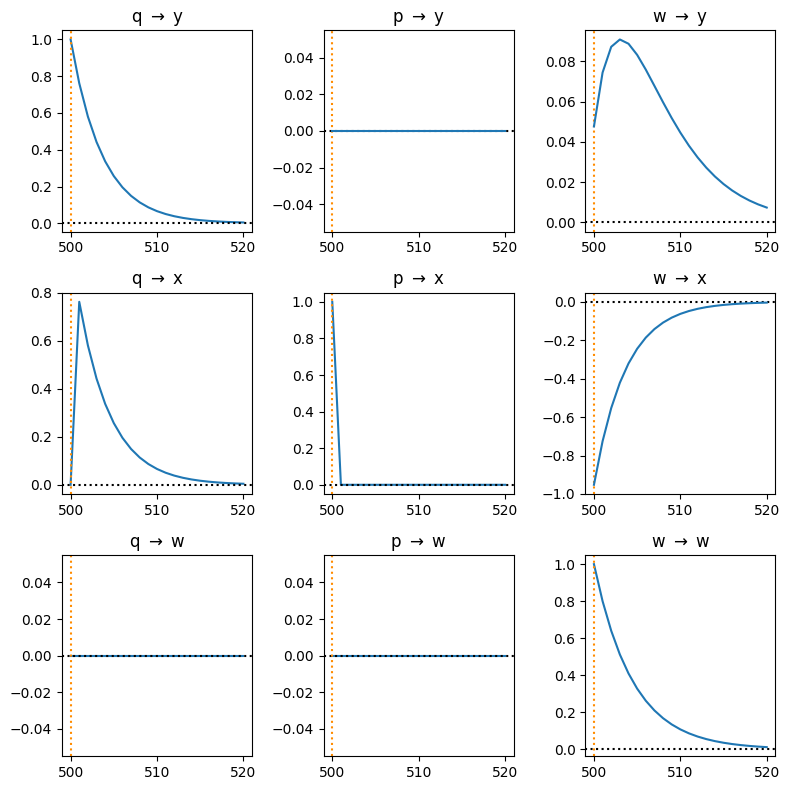

In [86]:
plot_irf_panel(500, ["q", "p", "w"])

y    1.0
x    0.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y   -0.05
x    1.00
w    0.00
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y    0.047619
x   -0.952381
w    1.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\2585303229.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


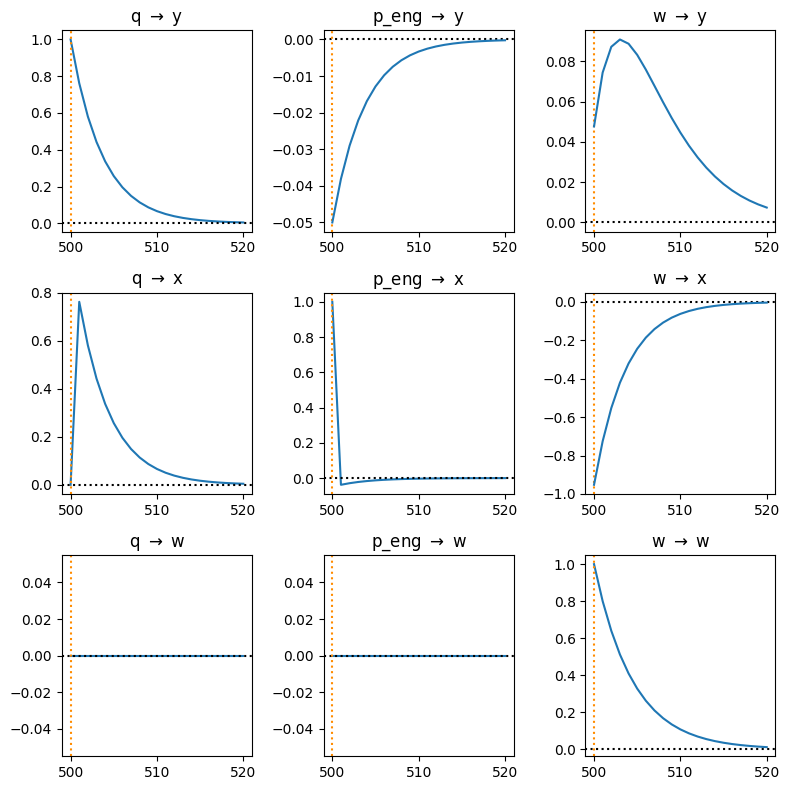

In [88]:
plot_irf_panel(500, ["q", "p_eng", "w"])


[[ 1.         -0.28954114  0.        ]
 [ 0.          1.          0.95845023]
 [ 0.          0.          1.        ]]


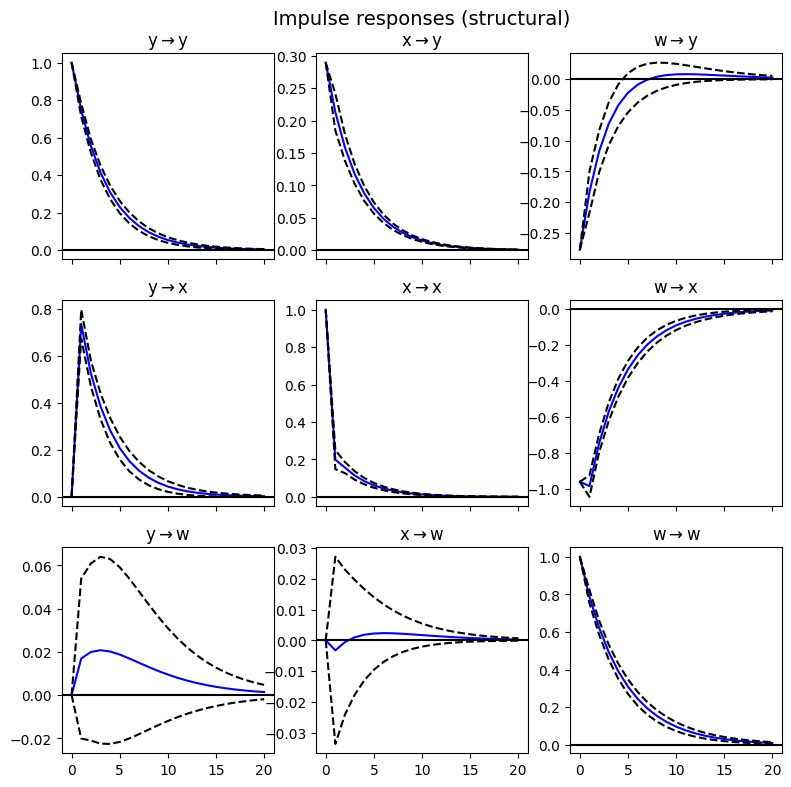

In [26]:
print(var_result.A)
fig = irf.plot(figsize=(8, 8))

In [27]:
def plot_cum_effects_panel(shock_pos:int, shock_vars:list[str]):
    fig, axss = plt.subplots(3, 3, figsize=(8, 8))

    for i, sv in enumerate(shock_vars):
        df_shock,_ = generate_economic_data_DAG1(1000, shock=True, shock_pos=shock_pos, shock_var=sv)
        df_no_shock,_ = generate_economic_data_DAG1(1000, shock=False, shock_pos=shock_pos, shock_var=sv)

        lb = shock_pos - 0
        ub = shock_pos + 20
        df_shock = cut_data(df_shock, lb, ub+1)
        df_no_shock = cut_data(df_no_shock, lb, ub+1)
        df_diff = difference(df_shock, df_no_shock)

        df_cum = df_diff.cumsum()
        

        axss[0][i].plot(df_cum["y"])
        axss[0][i].set_title(f"{sv} $\\rightarrow$ y")
        axss[1][i].plot(df_cum["x"])
        axss[1][i].set_title(f"{sv} $\\rightarrow$ x")
        axss[2][i].plot(df_cum["w"])
        axss[2][i].set_title(f"{sv} $\\rightarrow$ w")
        for ax in axss[i]:
            ax.axhline(0, ls=":", color="k")
            ax.axvline(shock_pos, ls=":", color="darkorange")
            ax.set_xlim(lb-1, ub+1)

        print(df_cum[["y", "x", "w"]].loc[shock_pos])

        fig.tight_layout()
        fig.show()

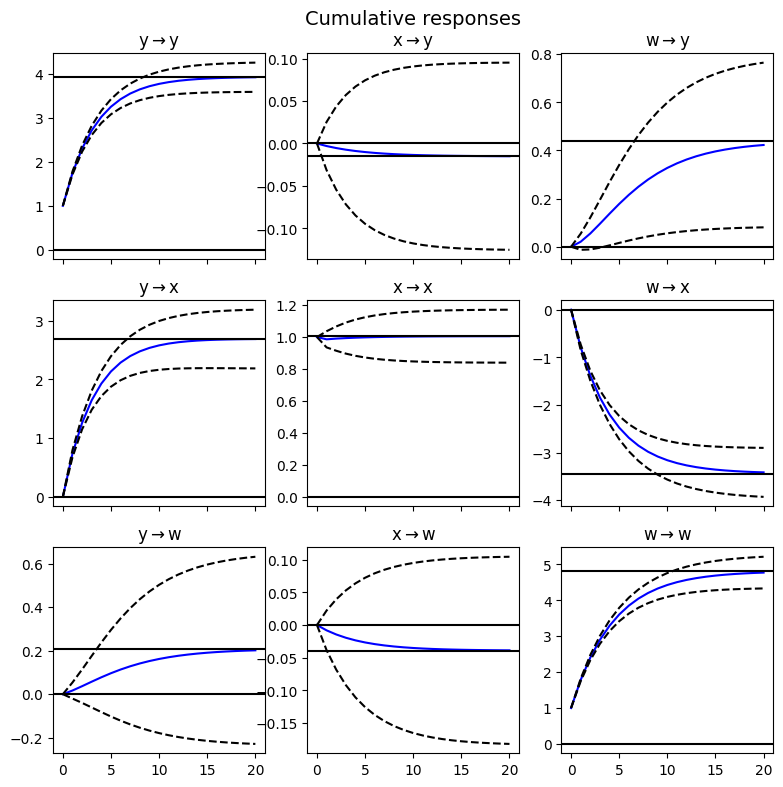

In [28]:
fig = irf.plot_cum_effects(figsize=(8, 8), subplot_params={"ylim":(-1, 4)})

y    1.0
x    0.0
w    0.0
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1726842390.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y   -0.05
x    1.00
w    0.00
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1726842390.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


y    0.047619
x   -0.952381
w    1.000000
Name: 500, dtype: float64


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\1726842390.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


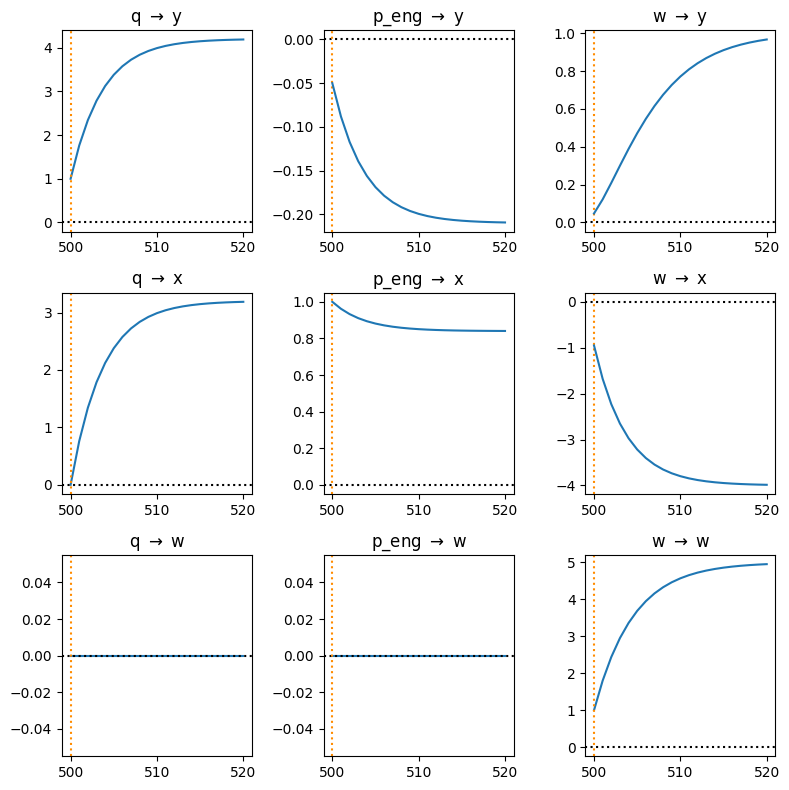

In [29]:
plot_cum_effects_panel(500, ["q", "p_eng", "w"])


# DAG-based IRFs

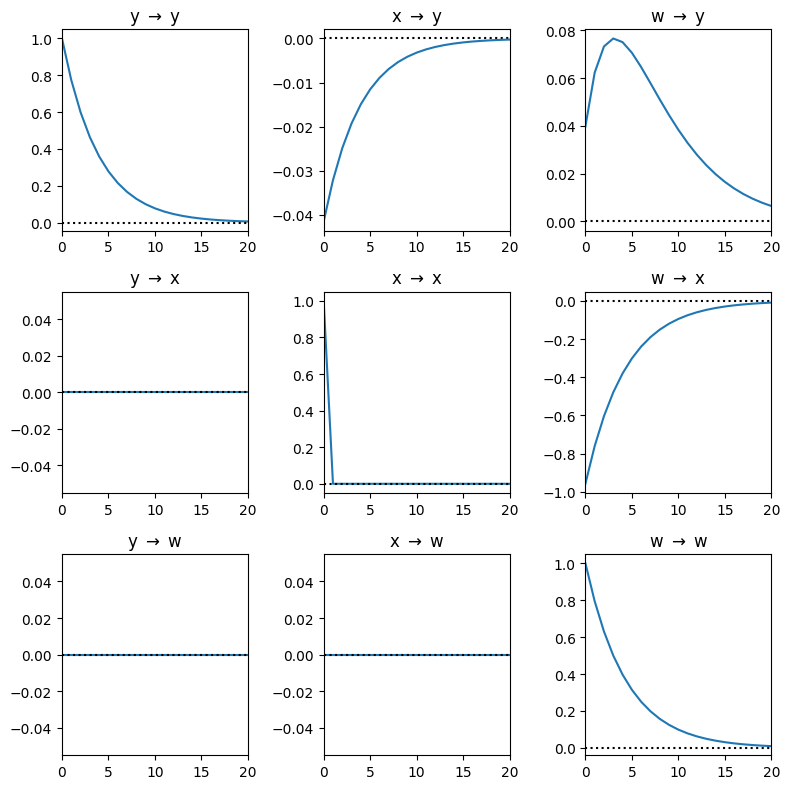

In [30]:
def dag_based_irfs():
    data, _ = generate_economic_data_DAG1(4000, seasonality=True, shock=False)
    data = data.dropna()

    # coeff of wind to price
    wind_X = sm.add_constant(data[['h', 'w_lag1']])
    wind_reg = sm.OLS(data['w'], wind_X, missing="drop").fit()
    wt_to_wt1 = wind_reg.params['w_lag1']
    ci_wind = wind_reg.conf_int(alpha=0.05).loc['w_lag1'].values  # [lower, upper]

    first_stage_X = sm.add_constant(data[['w', 'h', 'w_lag1', 'y_lag1']])
    first_stage = sm.OLS(data['x'], first_stage_X, missing="drop").fit()
    wt_to_xt = first_stage.params['w']

    # Second stage: y ~ x_hat + controls
    data['x_hat'] = first_stage.predict()
    second_stage_X = sm.add_constant(data[['x_hat', 'h', 'w_lag1', 'y_lag1']])
    second_stage = sm.OLS(data['y'], second_stage_X).fit()

    xt_to_yt = second_stage.params['x_hat']
    yt_to_yt1 = second_stage.params['y_lag1']


    def sim_irfs(shock_var:str, n_obs:int) -> pd.DataFrame:
        y = np.zeros(n_obs)  # y -> demanded and equilibrium quantity
        x = np.zeros(n_obs)  # p -> equilibrium prices
        w = np.zeros(n_obs)  # Confounder variable -> seasonality -> must be controlled on

        match shock_var:
            case "y":
                y[0] = 1
            case "x":
                x[0] = 1
            case "w":
                w[0] = 1
            
        for t in range(n_obs):
            w[t] += (wt_to_wt1 * w[t-1] if t > 0 else 0)
            x[t] += wt_to_xt * w[t]
            y[t] += (yt_to_yt1 * y[t-1] if t > 0 else 0) + xt_to_yt * x[t]

        irf_data = pd.DataFrame({
            'y': y,
            'x': x,
            'w': w,
        })

        return irf_data


    fig, axss = plt.subplots(3, 3, figsize=(8, 8))

    for i, sv in enumerate(['y', 'x', 'w']):

        df = sim_irfs(sv, 21)
    
        axss[0][i].plot(df["y"])
        axss[0][i].set_title(f"{sv} $\\rightarrow$ y")
        axss[1][i].plot(df["x"])
        axss[1][i].set_title(f"{sv} $\\rightarrow$ x")
        axss[2][i].plot(df["w"])
        axss[2][i].set_title(f"{sv} $\\rightarrow$ w")
        for ax in axss[i]:
            ax.axhline(0, ls=":", color="k")
            ax.axvline(shock_pos, ls=":", color="darkorange")
            ax.set_xlim(0, 20)

    fig.tight_layout()
    



dag_based_irfs()

In [31]:
def dag_based_irfs_with_ci():
    import numpy as np
    import pandas as pd
    import statsmodels.api as sm
    import matplotlib.pyplot as plt

    data, _ = generate_economic_data_DAG1(4000, seasonality=True, shock=False)
    data = data.dropna()

    # --------------------------------------------------
    # Fit regressions and get point estimates + CIs
    # --------------------------------------------------
    # coeff of wind to next-period wind (w_lag1 -> w)
    wind_X = sm.add_constant(data[['h', 'w_lag1']])
    wind_reg = sm.OLS(data['w'], wind_X, missing="drop").fit()
    wt_to_wt1 = wind_reg.params['w_lag1']
    ci_wind = wind_reg.conf_int(alpha=0.05).loc['w_lag1'].values  # [lower, upper]

    # first stage: w -> x (with controls)
    first_stage_X = sm.add_constant(data[['w', 'h', 'w_lag1', 'y_lag1']])
    first_stage = sm.OLS(data['x'], first_stage_X, missing="drop").fit()
    wt_to_xt = first_stage.params['w']
    ci_first = first_stage.conf_int(alpha=0.05).loc['w'].values

    # second stage: y ~ x_hat + controls
    data['x_hat'] = first_stage.predict()
    second_stage_X = sm.add_constant(data[['x_hat', 'h', 'w_lag1', 'y_lag1']])
    second_stage = sm.OLS(data['y'], second_stage_X).fit()
    xt_to_yt = second_stage.params['x_hat']
    yt_to_yt1 = second_stage.params['y_lag1']
    ci_second_xt = second_stage.conf_int(alpha=0.05).loc['x_hat'].values
    ci_second_ytlag = second_stage.conf_int(alpha=0.05).loc['y_lag1'].values

    # Collect point and CI bounds
    params_point = {
        'wt_to_wt1': float(wt_to_wt1),
        'wt_to_xt': float(wt_to_xt),
        'xt_to_yt': float(xt_to_yt),
        'yt_to_yt1': float(yt_to_yt1),
    }
    params_lower = {
        'wt_to_wt1': float(ci_wind[0]),
        'wt_to_xt': float(ci_first[0]),
        'xt_to_yt': float(ci_second_xt[0]),
        'yt_to_yt1': float(ci_second_ytlag[0]),
    }
    params_upper = {
        'wt_to_wt1': float(ci_wind[1]),
        'wt_to_xt': float(ci_first[1]),
        'xt_to_yt': float(ci_second_xt[1]),
        'yt_to_yt1': float(ci_second_ytlag[1]),
    }

    # --------------------------------------------------
    # IRF simulator that accepts custom parameter values
    # --------------------------------------------------
    def sim_irfs(shock_var: str, n_obs: int, params: dict) -> pd.DataFrame:
        y = np.zeros(n_obs)
        x = np.zeros(n_obs)
        w = np.zeros(n_obs)

        # set initial shock
        if shock_var == "y":
            y[0] = 1
        elif shock_var == "x":
            x[0] = 1
        elif shock_var == "w":
            w[0] = 1

        for t in range(n_obs):
            if t > 0:
                w[t] += params['wt_to_wt1'] * w[t - 1]
                y[t] += params['yt_to_yt1'] * y[t - 1]
            # contemporaneous effects
            x[t] += params['wt_to_xt'] * w[t]
            y[t] += params['xt_to_yt'] * x[t]

        return pd.DataFrame({'y': y, 'x': x, 'w': w})

    # --------------------------------------------------
    # Plotting: central + dashed CI bounds
    # --------------------------------------------------
    fig, axss = plt.subplots(3, 3, figsize=(8, 8))
    shock_pos = 0

    for i, sv in enumerate(['y', 'x', 'w']):
        # central / lower / upper simulations
        df_center = sim_irfs(sv, 21, params_point)
        df_lower = sim_irfs(sv, 21, params_lower)
        df_upper = sim_irfs(sv, 21, params_upper)

        # plot central (solid)
        axss[0, i].plot(df_center["y"], label='point')
        axss[0, i].set_title(f"{sv} $\\rightarrow$ y")
        # plot CI bounds (dashed)
        axss[0, i].plot(df_lower["y"], ls='--', label='CI (95%)', color="k")
        axss[0, i].plot(df_upper["y"], ls='--', color="k")

        axss[1, i].plot(df_center["x"])
        axss[1, i].set_title(f"{sv} $\\rightarrow$ x")
        axss[1, i].plot(df_lower["x"], ls='--', color="k")
        axss[1, i].plot(df_upper["x"], ls='--', color="k")

        axss[2, i].plot(df_center["w"])
        axss[2, i].set_title(f"{sv} $\\rightarrow$ w")
        axss[2, i].plot(df_lower["w"], ls='--', color="k")
        axss[2, i].plot(df_upper["w"], ls='--', color="k")

        # add horizontal/vertical markers and set x-limits on the column of axes
        for ax in axss[:, i]:
            ax.axhline(0, ls=":", color="k")
            ax.axvline(shock_pos, ls=":", color="darkorange")
            ax.set_xlim(0, 20)

    # optional legend on the first column's top plot
    axss[0, 0].legend(loc='upper right', fontsize='small')

    fig.tight_layout()
    plt.show()

    # also return objects in case caller wants them
    return {
        'fig': fig,
        'params_point': params_point,
        'params_lower': params_lower,
        'params_upper': params_upper,
        'models': {
            'wind_reg': wind_reg,
            'first_stage': first_stage,
            'second_stage': second_stage
        }
    }


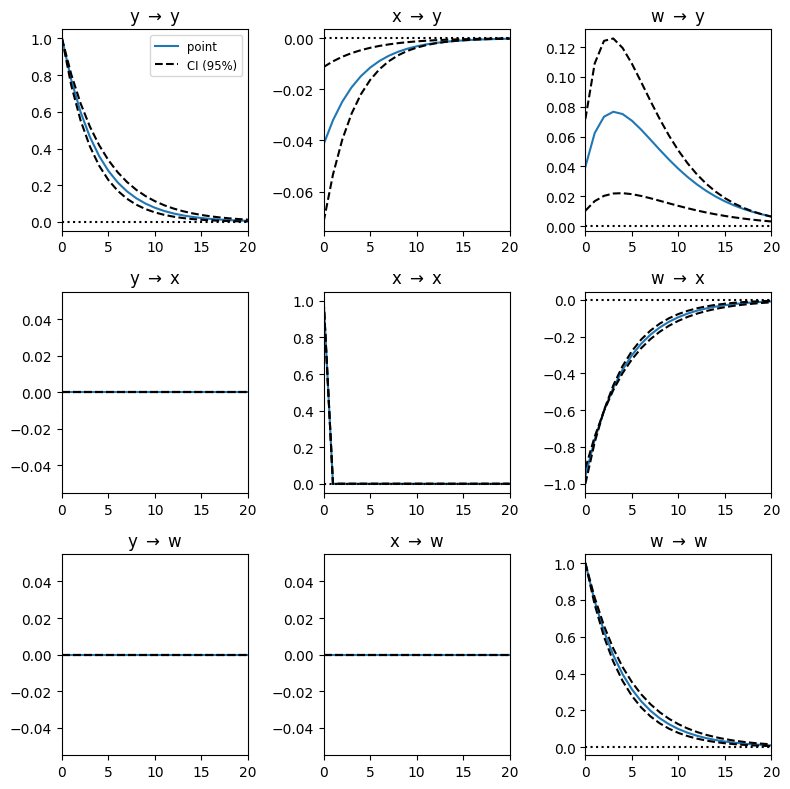

{'fig': <Figure size 800x800 with 9 Axes>,
 'params_point': {'wt_to_wt1': 0.7937260942789781,
  'wt_to_xt': -0.9581565161936554,
  'xt_to_yt': -0.0414934380523636,
  'yt_to_yt1': 0.7741810167956795},
 'params_lower': {'wt_to_wt1': 0.774865567998021,
  'wt_to_xt': -1.0003973383477245,
  'xt_to_yt': -0.07170892794724645,
  'yt_to_yt1': 0.7441151011006523},
 'params_upper': {'wt_to_wt1': 0.8125866205599352,
  'wt_to_xt': -0.9159156940395862,
  'xt_to_yt': -0.01127794815748074,
  'yt_to_yt1': 0.8042469324907068},
 'models': {'wind_reg': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1ed46bbb150>,
  'first_stage': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1ed46bbb850>,
  'second_stage': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1ed4457bc70>}}

In [32]:
dag_based_irfs_with_ci()

# IV-SVAR analysis

In [66]:
def IV_svar_analysis(data, lags=1, verbose:bool=True):
    """Estimate SVAR with identifying restrictions"""
    
    # Prepare data - include all endogenous variables
    data['x_hat'] = sm.OLS(data[['x']], sm.add_constant(data['w'])).fit().predict()
    svar_data = data[['y', 'x_hat']].astype(float)  # ensure numeric dtype

    print(svar_data)
    A_mask = np.array([
        [1,    'E'],
        ["E",    1],
    ], dtype=object)

    # Reduced form VAR
    model = SVAR(endog=svar_data, svar_type="A", A=A_mask)
    if verbose:
        print("To be estimated:")
        print(model.A)
        print(model.A_mask)
        print(model.A[model.A_mask])
        print(len(model.A[model.A_mask]))
    var_result = model.fit(maxlags=lags)
    if verbose:
        print("Reduced Form SVAR Results:")
        print(model.A)
    
    return var_result, svar_data

In [67]:
svar_data, true_effect = generate_economic_data_DAG1(4000, seasonality=False)
# svar_data.to_csv('svar_iv_data.csv', index=False)



In [68]:
iv_svar_result, data = IV_svar_analysis(svar_data)

               y       x_hat
0     123.689159  112.899657
1     122.985369  112.913967
2     122.337850  112.889770
3     122.244671  113.080610
4     122.536542  112.940101
...          ...         ...
3995  123.384269  111.782436
3996  122.929517  111.555422
3997  122.459538  111.915991
3998  122.032638  111.995088
3999  122.335771  111.964854

[4000 rows x 2 columns]
To be estimated:
[[ 1. nan]
 [nan  1.]]
[[False  True]
 [ True False]]
[nan nan]
2
Reduced Form SVAR Results:
[[ 1.          1.9640385 ]
 [-1.88158527  1.        ]]


In [69]:
irf = iv_svar_result.irf(20)

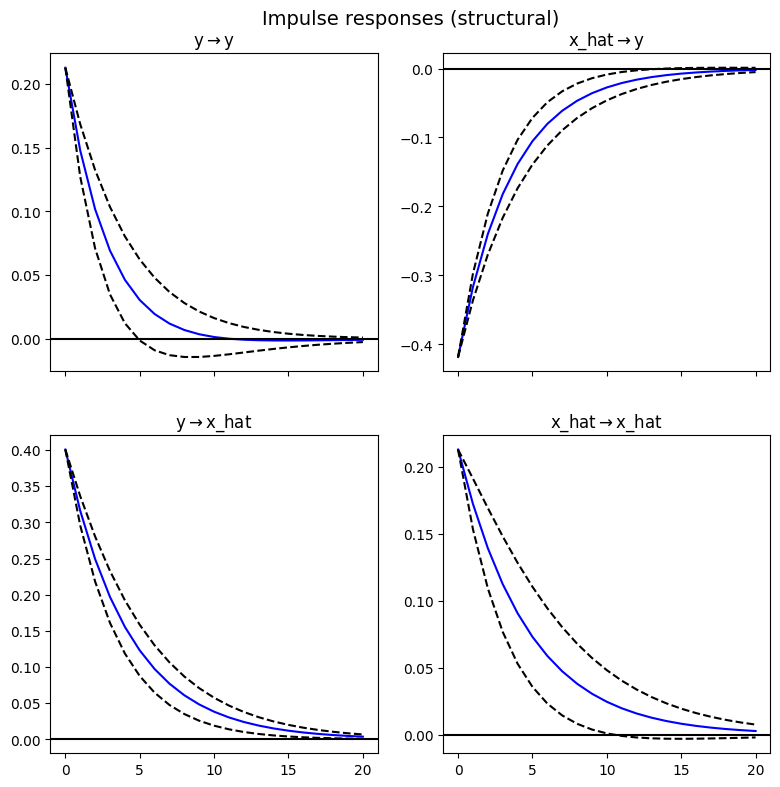

In [70]:
# fig = irf.plot(impulse="w", figsize=(8, 6))
fig = irf.plot(figsize=(8, 8))

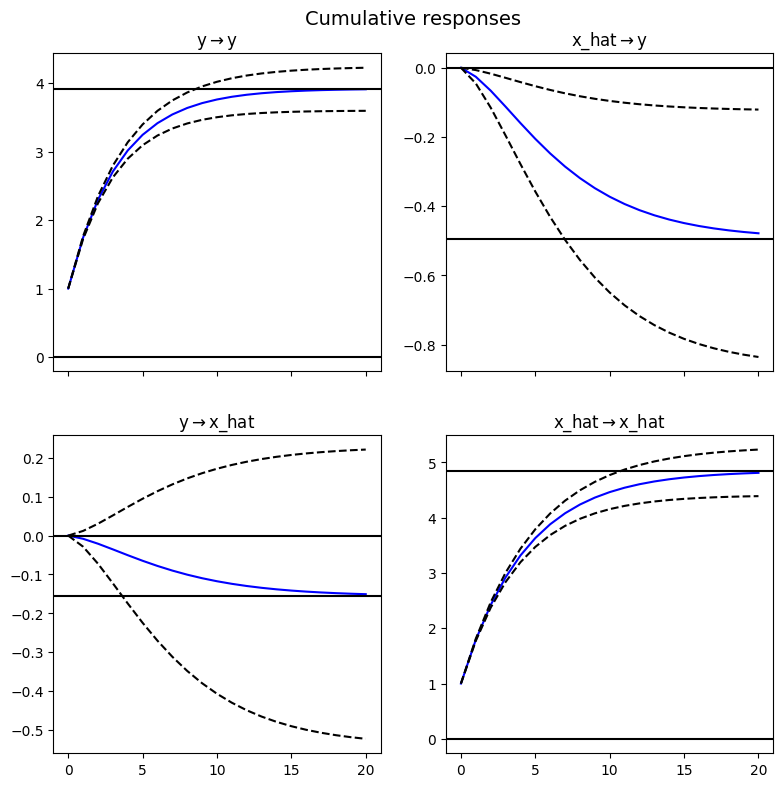

In [71]:
fg = irf.plot_cum_effects(figsize=(8, 8))

# Wind residual SVAR

In [81]:
def IV_svar_analysis(data, lags=1, verbose:bool=True):
    """Estimate SVAR with identifying restrictions"""
    data = data.dropna()
    # Prepare data - include all endogenous variables
    data['u^w'] = sm.OLS(data[['w']], sm.add_constant(data['w_lag1'])).fit().predict()
    svar_data = data[['y', 'x', 'u^w']].astype(float)  # ensure numeric dtype

    print(svar_data)
    A_mask = np.array([
        [1,    'E',     0],
        ["E",    1,     "E"],
        [0,    0,     1],
    ], dtype=object)

    # Reduced form VAR
    model = SVAR(endog=svar_data, svar_type="A", A=A_mask)
    if verbose:
        print("To be estimated:")
        print(model.A)
        print(model.A_mask)
        print(model.A[model.A_mask])
        print(len(model.A[model.A_mask]))
    var_result = model.fit(maxlags=lags)
    if verbose:
        print("Reduced Form SVAR Results:")
        print(model.A)
    
    return var_result, svar_data

In [82]:
wind_resid_svar_result, data = IV_svar_analysis(svar_data)

               y           x       u^w
3     122.244671  113.900754 -0.753664
4     122.536542  113.498886 -0.919249
5     122.744779  113.670001 -0.797335
6     121.922631  111.222158 -0.475445
7     122.804804  113.782076  0.370263
...          ...         ...       ...
3995  123.384269  112.637256  0.768242
3996  122.929517  112.111614  0.207126
3997  122.459538  111.318958  0.404098
3998  122.032638  110.913962  0.091246
3999  122.335771  112.247453  0.022616

[3997 rows x 3 columns]
To be estimated:
[[ 1. nan  0.]
 [nan  1. nan]
 [ 0.  0.  1.]]
[[False  True False]
 [ True False  True]
 [False False False]]
[nan nan nan]
3
Reduced Form SVAR Results:
[[ 1.          0.7905271   0.        ]
 [-2.23378261  1.          1.06890899]
 [ 0.          0.          1.        ]]


C:\Users\Jorge Sanchez\AppData\Local\Temp\ipykernel_131256\11428509.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['u^w'] = sm.OLS(data[['w']], sm.add_constant(data['w_lag1'])).fit().predict()
c:\Users\Jorge Sanchez\Documents\Github\elasticities_with_graphs\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Jorge Sanchez\Documents\Github\elasticities_with_graphs\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

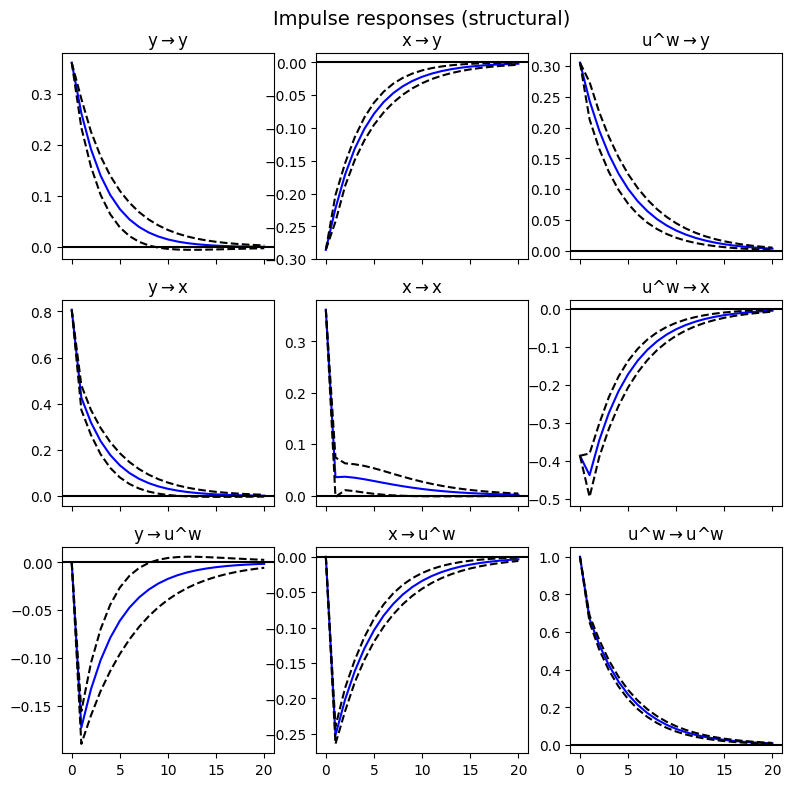

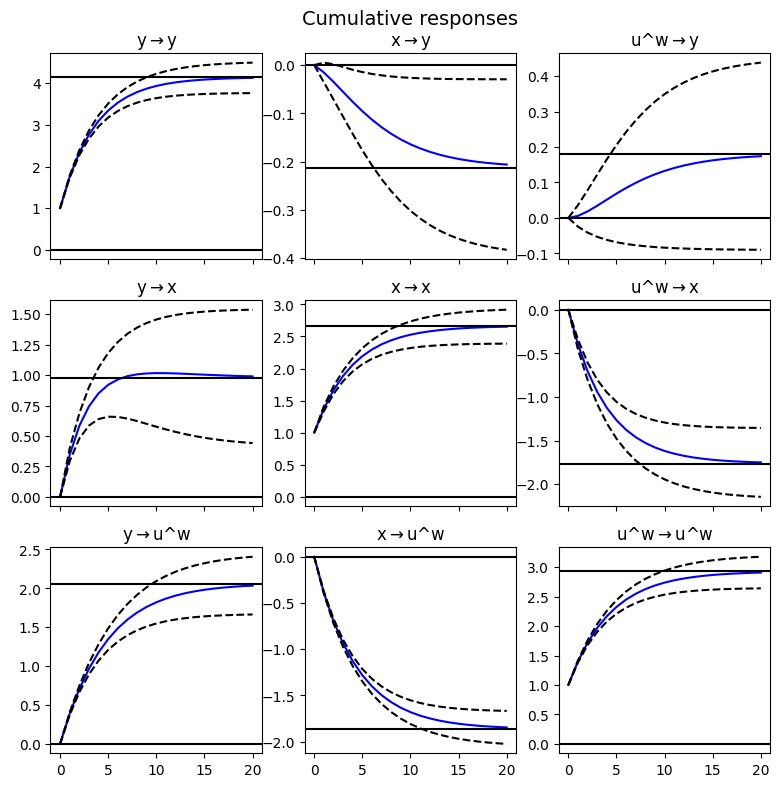

In [84]:
wind_resid_irf = wind_resid_svar_result.irf(20)
fig = wind_resid_irf.plot(figsize=(8, 8))
fig = wind_resid_irf.plot_cum_effects(figsize=(8, 8))


# VAR data

=== True structural parameters ===
A =
 [[ 1.   -0.25]
 [ 0.15  1.  ]]
B =
 [[0.8 0.2]
 [0.3 0.6]]

=== Reduced-form covariance of residuals Sigma_u ===
 [[0.83508297 0.3558346 ]
 [0.3558346  0.35532023]]

=== Cov(u, z) (proxy signal) ===
 [0.8308651  0.17847142]


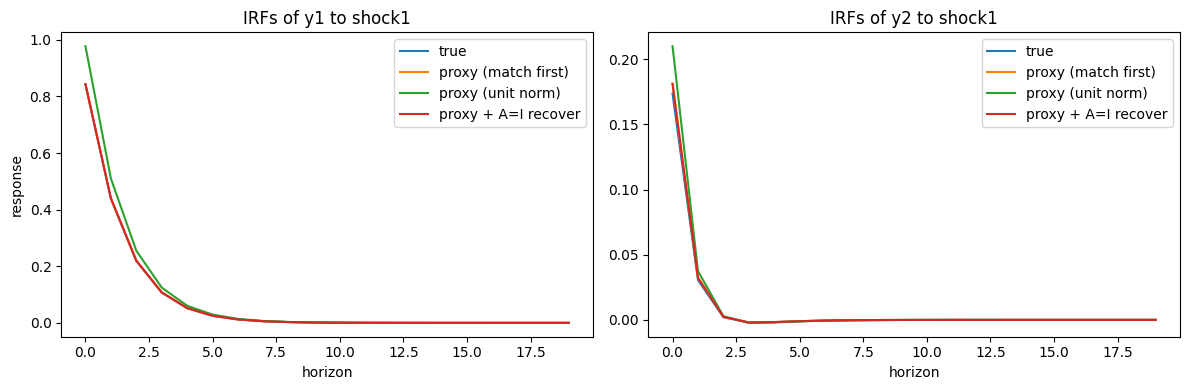

In [289]:
# Simulated hybrid SVAR + Proxy VAR example
# - 2-variable VAR(1) structural model
# - We'll simulate data from a known SVAR: A y_t = Phi y_{t-1} + B eps_t
# - eps_t ~ N(0, I)
# - We'll create an external instrument z_t that correlates with eps1_t only (plus noise)
# - We'll estimate a reduced-form VAR, compute the proxy-based impact vector (up to scale),
#   and show impulse responses for the instrumented shock.
# - We'll then "add" a simple SVAR assumption (A = I) and show how that extra restriction
#   helps recover the full impact matrix B (using orthogonality and Sigma_u = B B').
#
# Note: The proxy-based estimate identifies the impact vector up to scale. Here we normalize
# in two ways to illustrate results. This is a pedagogical simulation.
#
# Requirements from python_user_visible tool:
# - Use matplotlib (no seaborn) and do not explicitly set colors/styles.
# - Only one plot per chart.
# - Outputs will be displayed below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import inv, cholesky, svd, eig

np.random.seed(2025)

T = 2000  # sample size

# --- Structural parameters (true) ---
# A y_t = Phi y_{t-1} + B eps_t
A = np.array([[1.0, -0.25],
              [0.15, 1.0]])   # contemporaneous interactions (non-diagonal)
Phi = np.array([[0.5, 0.1],
                [0.05, 0.3]])   # structural lag matrix (1 lag)
B = np.array([[0.8, 0.2],
              [0.3, 0.6]])    # structural impact matrix (columns = shocks)

# Check that A is invertible
assert np.linalg.matrix_rank(A) == 2

# Simulate structural shocks eps_t ~ N(0, I)
eps = np.random.normal(size=(T, 2))

# Simulate data
y = np.zeros((T, 2))
for t in range(1, T):
    rhs = Phi @ y[t-1] + B @ eps[t]
    y[t] = np.linalg.solve(A, rhs)  # y_t = A^{-1} rhs

# Convert to pandas DataFrame for VAR estimation
dates = pd.date_range(start="2000-01-01", periods=T, freq='D')
df = pd.DataFrame(y, columns=["y1", "y2"], index=dates)

# --- Reduced-form VAR(1) estimation ---
model = VAR(df)
res = model.fit(1)
u = res.resid.values  # reduced-form residuals (T-1 x 2)
Sigma_u = np.cov(u.T, bias=True)

# --- Create external instrument (proxy) z_t ---
# z correlates with eps1 only: z = eps1 + noise. We'll align lengths (drop first obs from eps to match u)
eps_for_u = eps[1:]  # corresponds to u index
signal_to_noise = 0.6  # lower -> noisier instrument
z = eps_for_u[:, 0] + np.random.normal(scale=np.sqrt((1 - signal_to_noise) / signal_to_noise), size=T-1)
z = z.reshape(-1, 1)

# --- Proxy VAR identification (one-shot) ---
# Compute sample covariance between u and z: Sigma_u_z = E[u_t z_t]
Sigma_u_z = (u.T @ z) / (T-1)  # 2 x 1 vector
# Theory: Sigma_u_z is proportional to the reduced-form impact vector for the shock:
# Sigma_u_z = (A^{-1} b1) * cov(eps1, z). Hence Sigma_u_z is collinear with the reduced-form impact.
b_rf_proportional = Sigma_u_z.flatten()  # reduced-form impact up to scale

# Normalize the proxy-based impact vector in two ways:
# 1) Normalize so that the first element equals the true reduced-form impact first element.
#    Here we compute true reduced form immediate impact = A^{-1} B[:,0]
true_rf_impact = inv(A) @ B[:, 0]
scale1 = true_rf_impact[0] / b_rf_proportional[0]
b_rf_scaled_match_first = b_rf_proportional * scale1

# 2) Normalize so that the structural shock has unit variance in reduced form sense:
#    Often one normalizes structural shock variance to 1. We choose scale so that
#    var( (b_reduced' * eps1) ) = 1 -> scale = 1 / sqrt(b_rf_prop' * b_rf_prop)
scale2 = 1.0 / np.sqrt(b_rf_proportional @ b_rf_proportional)
b_rf_unit = b_rf_proportional * scale2

# --- Impulse responses for the instrumented shock using reduced-form companion ---
def compute_irfs(A0_inv_B_col, Phi_rf, nlags=20):
    # Phi_rf is the reduced-form VAR(1) companion A1 (2x2)
    # IRFs: psi_0 = impact vector, psi_h = Phi_rf^h * psi_0
    psi = [A0_inv_B_col.reshape(-1, 1)]
    cur = A0_inv_B_col.reshape(-1, 1)
    for h in range(1, nlags):
        cur = Phi_rf @ cur
        psi.append(cur)
    return np.hstack(psi)  # shape 2 x nlags

# Get reduced-form AR matrix (res.params gives intercept+lags; easier to use res.coefs)
Phi_rf = res.coefs[0]  # reduced-form A1
# IRFs: true (from structural simulation), proxy-based (scaled versions)
true_impact = inv(A) @ B[:, 0]
true_irfs = compute_irfs(true_impact, Phi_rf, nlags=20)
irfs_match_first = compute_irfs(b_rf_scaled_match_first, Phi_rf, nlags=20)
irfs_unit = compute_irfs(b_rf_unit, Phi_rf, nlags=20)

# --- Now: Add a simple SVAR assumption: A = I (zero contemporaneous restrictions) ---
# With A = I, reduced-form residuals satisfy u = B eps, so Sigma_u = B B'.
# If we know the first column of B (up to scale) from the proxy, we can recover the second column
# by solving Sigma_u - b1 b1' = b2 b2' (rank-1). We'll compute a b2 via Cholesky of the remainder.
# Use the b_rf_scaled_match_first as our estimate of b1 (interpreting it as structural b1 under A=I).
b1_hat = b_rf_scaled_match_first.flatten()
R = Sigma_u - np.outer(b1_hat, b1_hat)
# Ensure positive semi-definiteness (numerical)
eigvals = np.linalg.eigvals(R)
min_eig = np.min(eigvals)
if min_eig < -1e-8:
    print("Warning: remainder matrix not PSD; numerical issues may arise. min eig:", min_eig)
R_psd = (R + R.T) / 2
# If small negative eigenvalues, project to nearest PSD by clipping eigenvalues
eigvals, eigvecs = eig(R_psd)
eigvals_clipped = np.clip(eigvals, 0, None)
R_proj = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
# Cholesky may fail if rank-deficient; use SVD to extract a rank-1 column
U, svals, Vt = svd(R_proj)
# b2 candidate (up to sign) is sqrt(s1) * U[:,0]
if svals[0] <= 1e-12:
    b2_hat = np.zeros(2)
else:
    b2_hat = np.sqrt(svals[0]) * U[:, 0]
# Fix sign so that B determinant similar to true B (for interpretability)
if np.linalg.det(np.column_stack([b1_hat, b2_hat])) * np.linalg.det(B) < 0:
    b2_hat = -b2_hat

# Compute IRFs under A=I assumption with recovered B_hat
B_hat = np.column_stack([b1_hat, b2_hat])
# True IRFs under A=I case (for comparison we compute using reduced-form Phi_rf)
irfs_recovered = compute_irfs(B_hat[:, 0], Phi_rf, nlags=20)

# --- Summarize results in a small table and plots ---
irf_df = pd.DataFrame({
    'h': np.arange(20),
    'true_y1': true_irfs[0, :],
    'proxy_matchfirst_y1': irfs_match_first[0, :],
    'proxy_unit_y1': irfs_unit[0, :],
    'recovered_AeqI_y1': irfs_recovered[0, :],
    'true_y2': true_irfs[1, :],
    'proxy_matchfirst_y2': irfs_match_first[1, :],
    'proxy_unit_y2': irfs_unit[1, :],
    'recovered_AeqI_y2': irfs_recovered[1, :],
})

# Display a few summary numbers and the first 8 IRFs
summary_table = pd.DataFrame({
    "true_rf_impact": true_rf_impact,
    "b_rf_proportional": b_rf_proportional,
    "b_rf_scaled_match_first": b_rf_scaled_match_first,
    "b_rf_unit": b_rf_unit,
    "b1_hat_AeqI": b1_hat,
    "b2_hat_AeqI": b2_hat
}, index=["y1","y2"])

print("=== True structural parameters ===")
print("A =\n", A)
print("B =\n", B)
print("\n=== Reduced-form covariance of residuals Sigma_u ===\n", Sigma_u)
print("\n=== Cov(u, z) (proxy signal) ===\n", Sigma_u_z.flatten())

# # Show table of estimated impact vectors
# import caas_jupyter_tools as tools; tools.display_dataframe_to_user("Estimated impact vectors and comparison", summary_table)

# Plot IRFs: variable y1 and y2 responses to the instrumented shock (multiple normalizations)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(irf_df['h'], irf_df['true_y1'], label='true')
axes[0].plot(irf_df['h'], irf_df['proxy_matchfirst_y1'], label='proxy (match first)')
axes[0].plot(irf_df['h'], irf_df['proxy_unit_y1'], label='proxy (unit norm)')
axes[0].plot(irf_df['h'], irf_df['recovered_AeqI_y1'], label='proxy + A=I recover')
axes[0].set_title('IRFs of y1 to shock1')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('response')
axes[0].legend()

axes[1].plot(irf_df['h'], irf_df['true_y2'], label='true')
axes[1].plot(irf_df['h'], irf_df['proxy_matchfirst_y2'], label='proxy (match first)')
axes[1].plot(irf_df['h'], irf_df['proxy_unit_y2'], label='proxy (unit norm)')
axes[1].plot(irf_df['h'], irf_df['recovered_AeqI_y2'], label='proxy + A=I recover')
axes[1].set_title('IRFs of y2 to shock1')
axes[1].set_xlabel('horizon')
axes[1].legend()

plt.tight_layout()
plt.show()

# # Also show first 8 rows of IRFs DataFrame to the user
# tools.display_dataframe_to_user("First 8 horizons of IRFs (responses of y1 and y2)", irf_df.head(8))
